# Assignment 2 - Poject 7 Mixed Precision Training Strategy for VAE and VQ-VAE


## Description
Variational Autoencoders (VAE) and Vector Quantized Variational Autoencoders (VQ-VAE) are powerful generative models used in the field of deep learning for unsupervised learning tasks. This project aims to compare the performance of these models on three benchmark datasets: CIFAR-10, MNIST, and Fashion-MNIST. A key aspect of this comparison will be the use of normal and mixed precision training approaches, which have implications for training efficiency and model accuracy.

### Objectives

 - Implement VAE and VQ-VAE models in a deep learning framework
 - Train and evaluate these models on CIFAR-10, MNIST, and Fashion-MNIST datasets
 - Compare the performance of each model using normal and mixed precision training methods.
- Analyze the effects of precision training on the efficiency and accuracy of the models.

### notes on approach - A

- implimentation
    - VAE and VQ-VAE
- train both on each dataset
- comparison
    - mixed vs normal precision training
- analysis 
    - generation quality and reconstruction quality
    - training efficency
    - accuacay and preformance trade-offs
    

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import time
import pathlib as Path
import sys
import pandas as pd
from tqdm import tqdm


import torchvision.utils as vutils


### Import SRC files 

In [2]:
from src.config import *
import src.datafunctions as DF
import src.vq_vae as VQ 


In [3]:
#Make sure GPU torch is instaled and available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
#Check if GPU is available and set device accordingly
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
def show_batch(images, n=8, title="Batch"):
    images = images[:n].cpu()
    grid = make_grid(images, nrow=n, padding=2)
    plt.figure(figsize=(n * 1.5, 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray" if images.shape[1] == 1 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [5]:
mnist_train, mnist_test, mnist_in_channels, mnist_input_size = DF.get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
fashion_mnist_train, fashion_mnist_test, fashion_mnist_in_channels, fashion_mnist_input_size = DF.get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="fashion-mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
cifar10_train, cifar10_test, cifar10_in_channels, cifar10_input_size = DF.get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="cifar10",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

torch.Size([128, 1, 28, 28]) torch.Size([128])


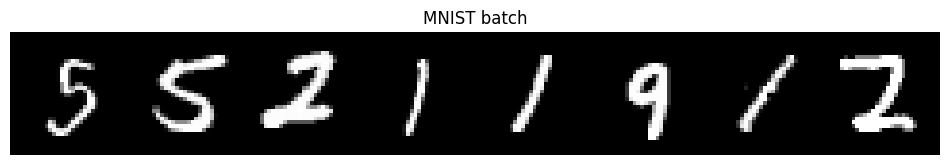

torch.Size([128, 1, 28, 28]) torch.Size([128])


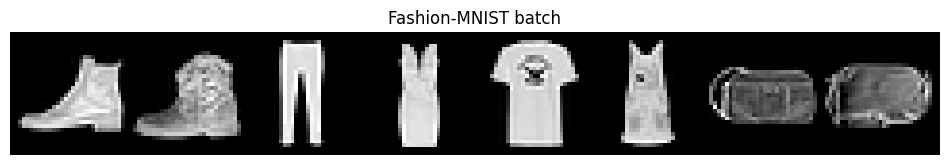

torch.Size([128, 3, 32, 32]) torch.Size([128])


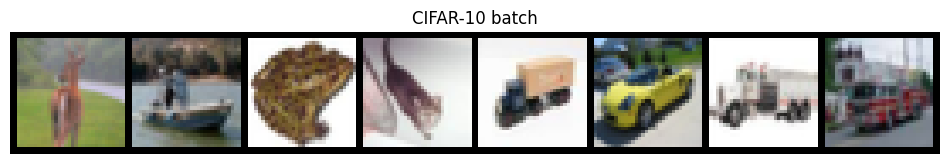

In [6]:
mnist_images, labels = next(iter(mnist_train))
fashion_mnist_images, labels1 = next(iter(fashion_mnist_train))
cifar10_images, labels2 = next(iter(cifar10_train))

print(mnist_images.shape, labels.shape)
show_batch(mnist_images, title="MNIST batch")
print(fashion_mnist_images.shape, labels1.shape)
show_batch(fashion_mnist_images, title="Fashion-MNIST batch")
print(cifar10_images.shape, labels2.shape)
show_batch(cifar10_images, title="CIFAR-10 batch")

## VQ-VAE dev section

Add complexity, by introducing up- down- and res- blocks that can be tuned 

In [8]:
# The number of code book embeddings
code_book_size = 32

# The number of latent embedding channels
hidden_channels = 10

# Number of Training epochs
vq_nepoch = 5

# Create our network
vae_net = VQ.VQVAE2(in_channels=mnist_in_channels, hidden_channels=hidden_channels, latent_dim=LATENT_DIM,
                code_book_size=code_book_size, commitment_cost=0.25).to(device)

# Setup optimizer
optimizer = optim.Adam(vae_net.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler('cuda')

lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=vq_nepoch, eta_min=0)

# Create loss logger
recon_loss_log = []
qv_loss_log = []
test_recon_loss_log = []
train_loss = 0


In [9]:
# Let's see how many Parameters our Model has!
num_model_params = 0
for param in vae_net.parameters():
    num_model_params += param.flatten().shape[0]

print("-The VQVAE Model Has %d (Approximately %d Million) Parameters!" % (num_model_params, 
                                                                          num_model_params//1e6))

-The VQVAE Model Has 21603 (Approximately 0 Million) Parameters!


In [10]:
# Pass through a test image to make sure everything is working
recon_data, vq_loss, quantized, encoding_indices = vae_net(mnist_images.to(device))

# View the Latent vector shape
quantized.shape

torch.Size([128, 64, 7, 7])

In [30]:
pbar = tqdm(range(0, vq_nepoch), leave=False, desc="Epoch")
for epoch in pbar:
    pbar.set_postfix_str('Loss: %.4f' % (train_loss/len(mnist_train)))
    train_loss = 0
    vae_net.train()
    for i, data in enumerate(tqdm(mnist_train, leave=False, desc="Training")):

        image = data[0].to(device)
        with torch.amp.autocast('cuda'):
            # Forward pass the image in the data tuple
            recon_data, vq_loss, quantized, encoding_indices = vae_net(image)

            # Calculate the loss
            recon_loss = (recon_data - image).pow(2).mean()
            loss = vq_loss + recon_loss

        # Take a training step
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Log the loss
        recon_loss_log.append(recon_loss.item())
        qv_loss_log.append(vq_loss.item())
        train_loss += recon_loss.item()
        
    lr_scheduler.step()

    vae_net.eval()
    for i, data in enumerate(tqdm(mnist_test, leave=False, desc="Testing")):
        image = data[0].to(device)
        with torch.amp.autocast('cuda'):
            with torch.no_grad():
                # Forward pass the image in the data tuple
                recon_data, vq_loss, quantized, encoding_indices = vae_net(image)

                # Calculate the loss
                recon_loss = (recon_data - image).pow(2).mean()
                loss = vq_loss + recon_loss
                test_recon_loss_log.append(recon_loss.item())

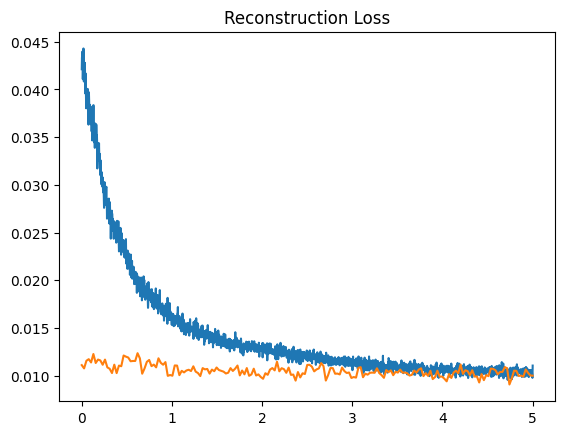

In [17]:
x_train = np.linspace(0, vq_nepoch, len(recon_loss_log[200:]))
_ = plt.plot(x_train, recon_loss_log[200:])

x_test = np.linspace(0, vq_nepoch, len(test_recon_loss_log[200:]))
_ = plt.plot(x_test, test_recon_loss_log[200:])
_ = plt.title("Reconstruction Loss")

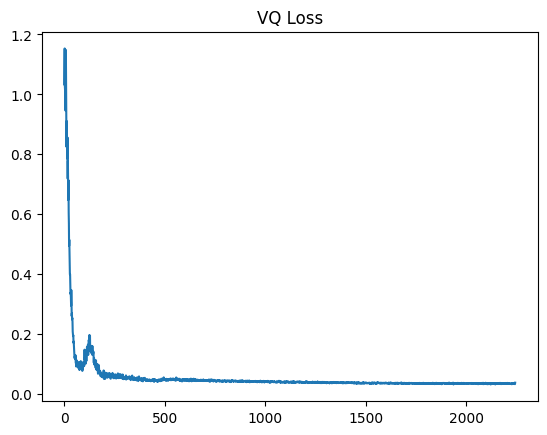

In [18]:
_ = plt.plot(qv_loss_log[100:])
_ = plt.title("VQ Loss")

In [21]:
vae_net.eval()
with torch.no_grad():
    recon_data, vq_loss, quantized, _ = vae_net(mnist_images.to(device))

In [22]:
vq_loss, quantized, encoding_indices = vae_net.encode(mnist_images.to(device))

In [23]:
encoding_indices[0]

tensor([[ 9,  9,  8,  8,  9, 11,  9],
        [ 9,  8,  0, 19, 20,  9,  9],
        [ 9,  8,  1, 14,  9, 11,  9],
        [ 9, 28,  1, 15, 20, 13,  9],
        [ 8,  9, 26, 21, 19, 11,  9],
        [ 9,  1, 10,  2,  3,  9,  9],
        [ 9, 31, 15,  3,  9,  9,  9]], device='cuda:0')

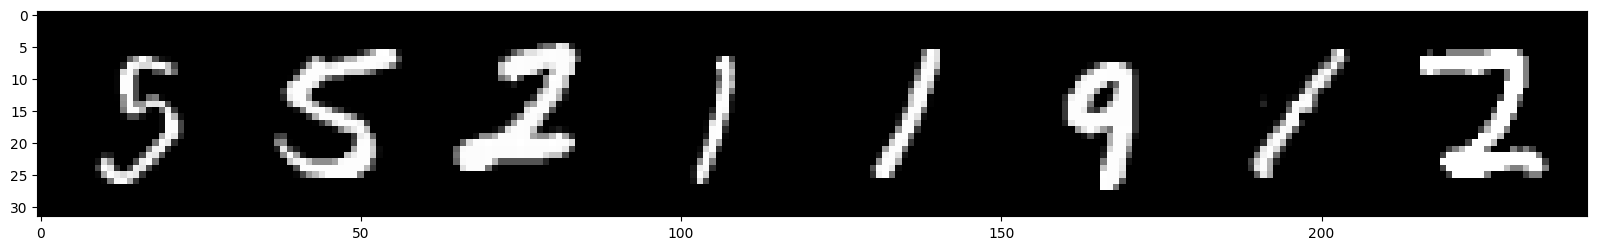

In [28]:
plt.figure(figsize = (20,10))
out = vutils.make_grid(mnist_images[0:8], normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))

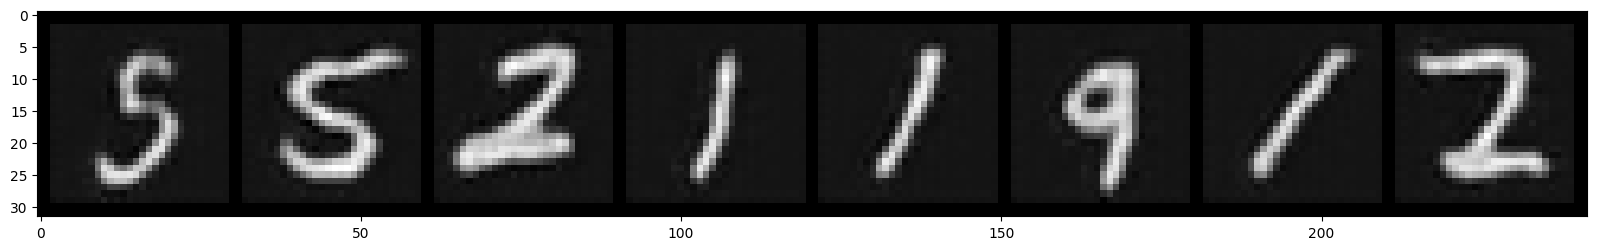

In [29]:
plt.figure(figsize = (20,10))
out = vutils.make_grid(recon_data.detach().cpu()[0:8], normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))